# Task 7: Diabetes Prediction
### Predict if a patient has diabetes based on age, BMI, and blood sugar level

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
import warnings; warnings.filterwarnings("ignore")


In [2]:
np.random.seed(42)
n = 50
ages       = np.random.randint(25, 70, n)
bmi        = np.round(np.random.uniform(18.5, 40.0, n), 1)
blood_sugar= np.random.randint(80, 280, n)
diabetes   = ((bmi > 30) | (blood_sugar > 140)).astype(int)
# Add some noise
flip = np.random.choice(n, 5, replace=False)
diabetes[flip] = 1 - diabetes[flip]

df = pd.DataFrame({"age": ages, "bmi": bmi, "blood_sugar": blood_sugar, "diabetes": diabetes})
df["label"] = df["diabetes"].map({1:"Diabetic", 0:"Non-Diabetic"})
print(df.head(15))
print("\nDiabetes Distribution:")
print(df["label"].value_counts())


    age   bmi  blood_sugar  diabetes         label
0    63  28.0          272         1      Diabetic
1    53  21.1          180         1      Diabetic
2    39  29.1          254         1      Diabetic
3    67  19.2          210         1      Diabetic
4    32  38.1           80         1      Diabetic
5    45  24.1           84         0  Non-Diabetic
6    63  32.7          221         1      Diabetic
7    43  25.2          182         1      Diabetic
8    47  29.7          106         0  Non-Diabetic
9    35  30.3          216         1      Diabetic
10   35  22.5           94         0  Non-Diabetic
11   48  39.3          169         1      Diabetic
12   60  35.2          121         1      Diabetic
13   64  38.7          203         1      Diabetic
14   48  37.7          258         1      Diabetic

Diabetes Distribution:
label
Diabetic        38
Non-Diabetic    12
Name: count, dtype: int64


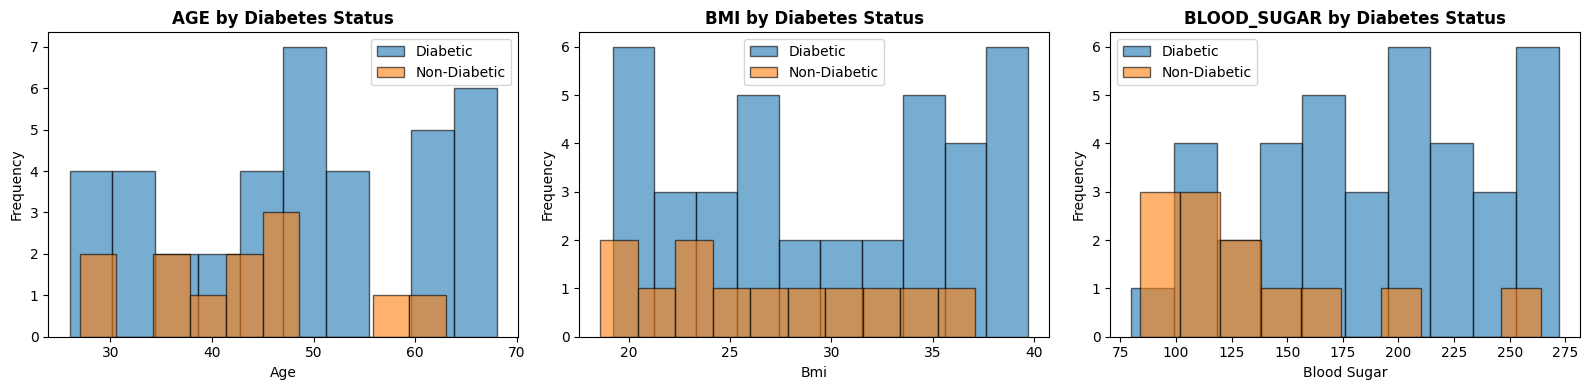

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feat in zip(axes, ["age","bmi","blood_sugar"]):
    df.groupby("label")[feat].plot(kind="hist", ax=ax, alpha=0.6, legend=True, edgecolor="black")
    ax.set_title(f"{feat.upper()} by Diabetes Status", fontweight="bold")
    ax.set_xlabel(feat.replace("_"," ").title())
plt.tight_layout(); plt.savefig("task7_viz.png", dpi=100); plt.show()


In [3]:
X = df[["age","bmi","blood_sugar"]]
y = df["diabetes"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(" Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic","Diabetic"]))


 Accuracy: 69.23 %

 Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.25      0.50      0.33         2
    Diabetic       0.89      0.73      0.80        11

    accuracy                           0.69        13
   macro avg       0.57      0.61      0.57        13
weighted avg       0.79      0.69      0.73        13



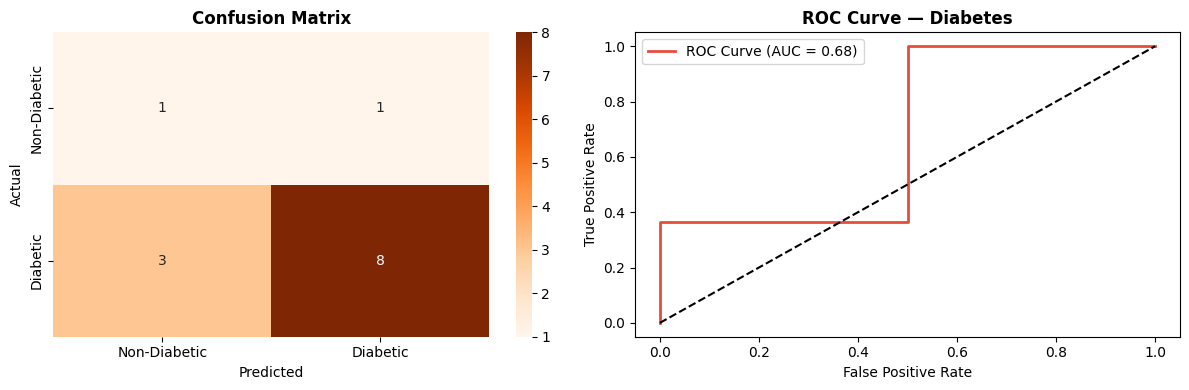

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", ax=axes[0],
            xticklabels=["Non-Diabetic","Diabetic"], yticklabels=["Non-Diabetic","Diabetic"])
axes[0].set_title("Confusion Matrix", fontweight="bold")
axes[0].set_ylabel("Actual"); axes[0].set_xlabel("Predicted")

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="#e74c3c", lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
axes[1].plot([0,1],[0,1],"k--")
axes[1].set_title("ROC Curve — Diabetes", fontweight="bold")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].legend(); plt.tight_layout(); plt.savefig("task7_roc.png", dpi=100); plt.show()
